## Notebook 03: Clasificación Temática
## Clasificación zero-shot de reseñas por temas organizacionales relevantes para el análisis de rotación

In [1]:
# --- Imports y carga ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from transformers import pipeline

# Cargar datos con sentimiento
muestra = pd.read_csv('../data/nlp/glassdoor_sentiment.csv')
print(f'Datos cargados: {muestra.shape}')

Datos cargados: (10000, 24)


In [2]:
# --- Clasificador zero-shot ---

# Temas relevantes para rotación laboral
temas = [
    'salary and compensation',
    'work life balance',
    'management and leadership',
    'career growth and development',
    'company culture',
    'communication and transparency',
    'job satisfaction',
    'workload and stress'
]

# Pipeline zero-shot
classifier = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=-1
)

# Probar
prueba = classifier('Low salary and no raises in 3 years', temas)
print(f'Tema: {prueba["labels"][0]}, Score: {prueba["scores"][0]:.3f}')
# Esperado: Tema: salary and compensation, Score: 0.8+

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

C:\Users\mario\Documents\Master\TFM\TFM-Employee-Attrition\venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mario\.cache\huggingface\hub\models--facebook--bart-large-mnli. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tema: salary and compensation, Score: 0.948


In [3]:
# --- Clasificación de temas (solo contras, donde estan las quejas = razones de rotación) ---
from tqdm import tqdm

print(f'Clasificando {len(muestra)} reseñas por tema...')

topic_results = []
for texto in tqdm(muestra['cons_clean'], desc='Topics'):
    result = classifier(texto, temas)
    topic_results.append({
        'tema': result['labels'][0],
        'score': round(result['scores'][0], 4)
    })

muestra['topic'] = [r['tema'] for r in topic_results]
muestra['topic_score'] = [r['score'] for r in topic_results]

print(f'\nDistribucion de temas:')
print(muestra['topic'].value_counts())

Clasificando 10000 reseñas por tema...


Topics: 100%|██████████| 10000/10000 [7:13:12<00:00,  2.60s/it]  


Distribucion de temas:
topic
workload and stress               3423
salary and compensation           1360
work life balance                 1288
company culture                   1240
management and leadership         1115
career growth and development      934
communication and transparency     416
job satisfaction                   224
Name: count, dtype: int64


In [4]:
muestra.to_csv('../data/nlp/glassdoor_topics.csv', index=False)
print('Datos con temas guardados')

Datos con temas guardados


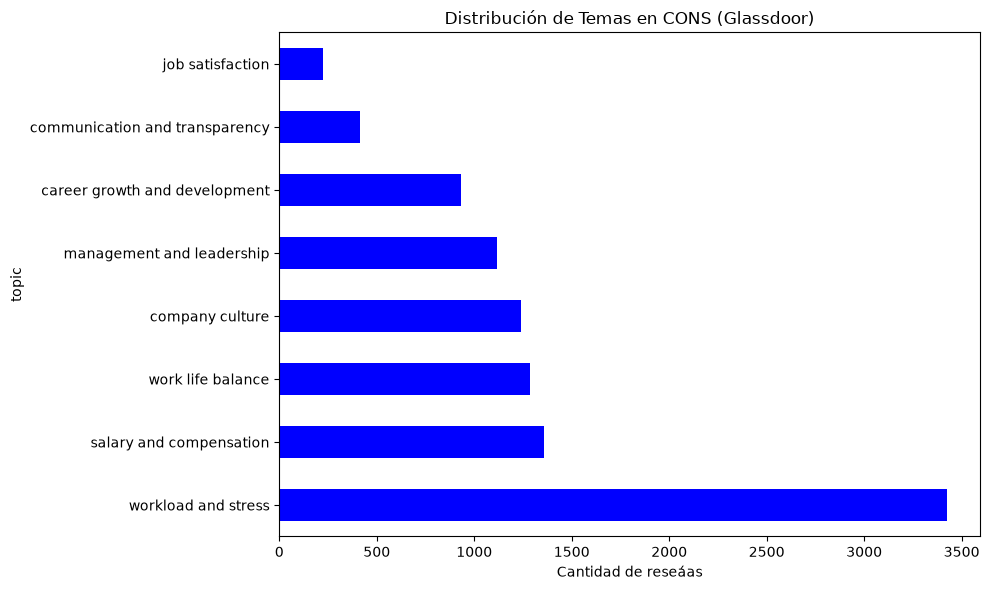

Muestra de 30 comentarios exportada para Kalil


In [8]:
# --- Gráficos de temas y muestra para Kalil ---

# Gráficos de distribución de temas
fig, ax = plt.subplots(figsize=(10, 6))
muestra['topic'].value_counts().plot(kind='barh', ax=ax, color='blue')
ax.set_title('Distribución de Temas en CONS (Glassdoor)')
ax.set_xlabel('Cantidad de reseáas')
plt.tight_layout()
plt.savefig('../reports/figures/topic_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Exportación de comentarios para revisión de Kalil
muestra_kalil = muestra[['cons', 'cons_sentiment', 'cons_score',
                              'topic', 'topic_score']].head(30)
muestra_kalil.to_csv('../data/nlp/Muestra_30_Comentarios.csv', index=False)
print('Muestra de 30 comentarios exportada para Kalil')

In [10]:
# Se tuvo que cargar los datos de otros notebooks (al parecer las variables no se comparten entre notebooks y dió error)
sentiment_data = pd.read_csv('../data/nlp/glassdoor_sentiment.csv')
topic_data = pd.read_csv('../data/nlp/glassdoor_topics.csv')

In [12]:
# --- Resumen NLP ---
print('=== RESUMEN NLP - GLASSDOOR ===')
print(f'\nSENTIMIENTO (n={len(sentiment_data)}):')
print(f'  Pros positivos: {(sentiment_data["pros_sentiment"]=="POSITIVE").mean()*100:.1f}%')
print(f'  Cons negativos: {(sentiment_data["cons_sentiment"]=="NEGATIVE").mean()*100:.1f}%')

print(f'\nTEMAS (n={len(topic_data)}):')
print(topic_data['topic'].value_counts(normalize=True).round(4))

print('\nNota: Glassdoor se usa como validación cualitativa del modelo predictivo IBM HR, no como features directas.')

=== RESUMEN NLP - GLASSDOOR ===

SENTIMIENTO (n=10000):
  Pros positivos: 91.8%
  Cons negativos: 85.4%

TEMAS (n=10000):
topic
workload and stress               0.3423
salary and compensation           0.1360
work life balance                 0.1288
company culture                   0.1240
management and leadership         0.1115
career growth and development     0.0934
communication and transparency    0.0416
job satisfaction                  0.0224
Name: proportion, dtype: float64

Nota: Glassdoor se usa como validación cualitativa del modelo predictivo IBM HR, no como features directas.
